# LOST - Continuous Mountain Car

In [2]:
import numpy as np
import gymnasium as gym
import random 

In [3]:
# Cambiar render_mode a rgb_array para entrenar/testear sino human
env_id = 'MountainCarContinuous-v0'
env = gym.make(env_id, render_mode='rgb_array')

In [4]:
from q_learning_agent import QLearningAgent

Observation Space

In [5]:
env.observation_space

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)

Action Space

In [6]:
env.action_space

Box(-1.0, 1.0, (1,), float32)

Discretización de los estados

In [7]:
x_space = np.linspace(-1.2, 0.6, 100)
vel_space = np.linspace(-0.07, 0.07, 100)
x_space

array([-1.2       , -1.18181818, -1.16363636, -1.14545455, -1.12727273,
       -1.10909091, -1.09090909, -1.07272727, -1.05454545, -1.03636364,
       -1.01818182, -1.        , -0.98181818, -0.96363636, -0.94545455,
       -0.92727273, -0.90909091, -0.89090909, -0.87272727, -0.85454545,
       -0.83636364, -0.81818182, -0.8       , -0.78181818, -0.76363636,
       -0.74545455, -0.72727273, -0.70909091, -0.69090909, -0.67272727,
       -0.65454545, -0.63636364, -0.61818182, -0.6       , -0.58181818,
       -0.56363636, -0.54545455, -0.52727273, -0.50909091, -0.49090909,
       -0.47272727, -0.45454545, -0.43636364, -0.41818182, -0.4       ,
       -0.38181818, -0.36363636, -0.34545455, -0.32727273, -0.30909091,
       -0.29090909, -0.27272727, -0.25454545, -0.23636364, -0.21818182,
       -0.2       , -0.18181818, -0.16363636, -0.14545455, -0.12727273,
       -0.10909091, -0.09090909, -0.07272727, -0.05454545, -0.03636364,
       -0.01818182,  0.        ,  0.01818182,  0.03636364,  0.05

Obtener el estado a partir de la observación

In [8]:
def get_state(obs):
    x, vel = obs
    x_bin = np.digitize(x, x_space)
    vel_bin = np.digitize(vel, vel_space)
    return x_bin, vel_bin

In [9]:
state = get_state(np.array([-0.4, 0.02]))
state

(np.int64(45), np.int64(64))

Discretización de las acciones

In [10]:
actions = list(np.linspace(-1, 1, 10))
actions

[np.float64(-1.0),
 np.float64(-0.7777777777777778),
 np.float64(-0.5555555555555556),
 np.float64(-0.33333333333333337),
 np.float64(-0.11111111111111116),
 np.float64(0.11111111111111116),
 np.float64(0.33333333333333326),
 np.float64(0.5555555555555554),
 np.float64(0.7777777777777777),
 np.float64(1.0)]

In [11]:
def get_sample_action():
    return random.choice(actions)

Inicilización de la tabla Q

In [12]:
Q = np.zeros((len(x_space) + 1, len(vel_space) + 1, len(actions)))
Q

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

Obtención de la acción a partir de la tabla Q

In [13]:
def optimal_policy(state, Q):
    action = actions[np.argmax(Q[state])]
    return action

Epsilon-Greedy Policy

In [14]:
def epsilon_greedy_policy(state, Q, epsilon=0.1):
    explore = np.random.binomial(1, epsilon)
    if explore:
        action = get_sample_action()
    else:
        action = optimal_policy(state, Q)
        
    return action

# No sé que era

In [14]:
# Testear el agente entrenado (sin exploración)
print("\nTesteando agente entrenado...")
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
test_rewards, test_steps = agent.test_agent(env, episodes=1, render=True)
env.close()

print(f"\nPromedio de rewards en testing: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps en testing: {np.mean(test_steps):.2f}")


Testeando agente entrenado...


NameError: name 'agent' is not defined

# Q-Learning Agent

-----------------------------------------------------

In [14]:
from q_learning_agent import QLearningAgent

In [15]:
from q_experiments_manager import ExperimentManager

# 1. Crear el entorno
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')

# 2. Inicializar el mánager de experimentos
manager = ExperimentManager()

----------------------------------------------------------------

Entrenando agente Q-Learning...

[8k_episodes_eps015] Iniciando experimento con Q-Table de tamaño: (101, 101, 20)
[8k_episodes_eps015] Ep 1600/8000 - Avg Reward: -96.85, Steps: 3000
[8k_episodes_eps015] Ep 3200/8000 - Avg Reward: -78.92, Steps: 3000
[8k_episodes_eps015] Ep 4800/8000 - Avg Reward: -61.92, Steps: 3000
[8k_episodes_eps015] Ep 6400/8000 - Avg Reward: -44.73, Steps: 3000
[8k_episodes_eps015] Ep 8000/8000 - Avg Reward: -26.65, Steps: 3000
--> Experimento '8k_episodes_eps015' guardado con éxito en el historial.


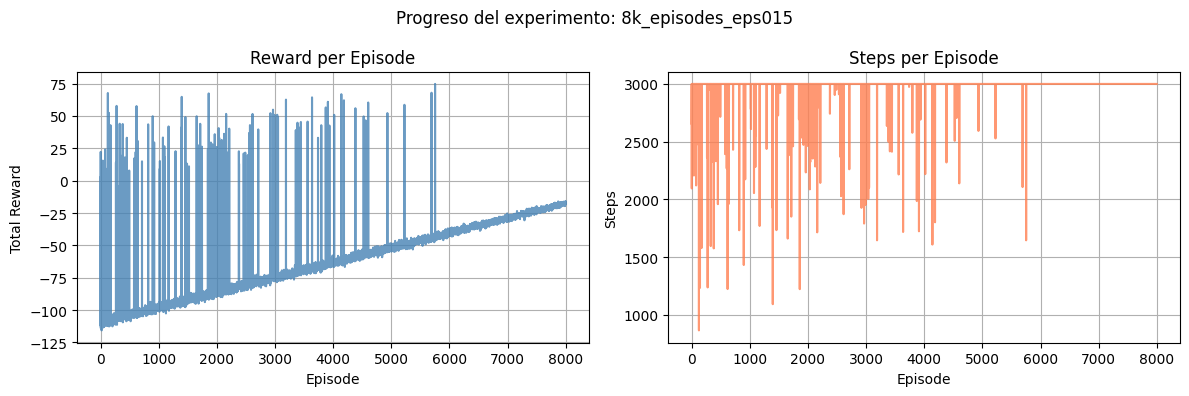

In [16]:
print("Entrenando agente Q-Learning...")
id_1 = "8k_episodes_eps015"
manager.train_run(
    env=env, 
    run_id=id_1,
    x_bins=100,         
    vel_bins=100,       
    action_bins=20,    
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.15,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamient0
manager.plot_training_history(id_1)


In [45]:
from dyna_q_agent import DynaQAgent

Entrenando agente Dyna-Q...
Episode 500/5000 - Avg Reward: -34.92, Steps: 1000, Success: 0.6%
Episode 1000/5000 - Avg Reward: -31.41, Steps: 655, Success: 1.0%
Episode 1500/5000 - Avg Reward: -22.84, Steps: 1000, Success: 6.8%
Episode 2000/5000 - Avg Reward: -3.76, Steps: 1000, Success: 22.8%
Episode 2500/5000 - Avg Reward: 20.28, Steps: 721, Success: 42.8%
Episode 3000/5000 - Avg Reward: 40.02, Steps: 1000, Success: 59.0%
Episode 3500/5000 - Avg Reward: 52.36, Steps: 589, Success: 69.0%
Episode 4000/5000 - Avg Reward: 67.82, Steps: 376, Success: 82.2%
Episode 4500/5000 - Avg Reward: 77.24, Steps: 234, Success: 89.4%
Episode 5000/5000 - Avg Reward: 88.10, Steps: 174, Success: 98.2%
Modelo guardado en dyna_agent_trained.npy


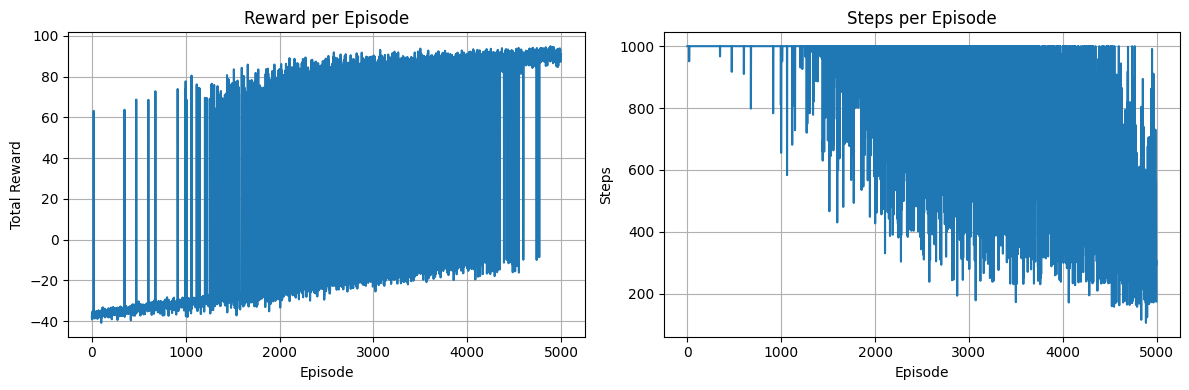

In [ ]:
# Crear agente con configuración inicial
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Dyna-Q...")
agent.train_agent(
    env, 
    episodes=5000,
    alpha=0.03,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.2,
    max_steps=1000,
    planning_steps=20
)
env.close()

# Guardar el modelo entrenado
agent.save_model('dyna_agent_trained.npy')

# Visualizar progreso de entrenamiento
agent.plot_training_history()

In [46]:
# Cargar un modelo Dyna-Q guardado y evaluarlo
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Evaluando el modelo cargado...")
test_rewards, test_steps, success_count = agent.test_agent(env, episodes=5, render=False)
env.close()

print(f"\nExitos en testing: {success_count}/5")
print(f"Promedio de rewards: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps: {np.mean(test_steps):.2f}")

Modelo cargado desde dyna_agent_trained.npy (Q shape: (101, 101, 20))
Evaluando el modelo cargado...
Test Episode 1 - Reward: 94.70, Steps: 225, Success: 1
Test Episode 2 - Reward: 94.65, Steps: 115, Success: 1
Test Episode 3 - Reward: -1.11, Steps: 4000, Success: 0
Test Episode 4 - Reward: 94.50, Steps: 333, Success: 1
Test Episode 5 - Reward: 94.80, Steps: 116, Success: 1

Exitos en testing: 4/5
Promedio de rewards: 75.51
Promedio de steps: 957.80


# Q-Learning variando el epsilon

In [15]:
from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')

Entrenando agente Q-Learning...

[8k_episodes_eps075] Iniciando experimento con Q-Table de tamaño: (101, 101, 20)
[8k_episodes_eps075] Ep 1600/8000 - Avg Reward: -94.85, Steps: 3000
[8k_episodes_eps075] Ep 3200/8000 - Avg Reward: -77.26, Steps: 3000
[8k_episodes_eps075] Ep 4800/8000 - Avg Reward: -58.27, Steps: 3000
[8k_episodes_eps075] Ep 6400/8000 - Avg Reward: -39.25, Steps: 3000
[8k_episodes_eps075] Ep 8000/8000 - Avg Reward: -19.31, Steps: 3000
--> Experimento '8k_episodes_eps075' guardado con éxito en el historial.


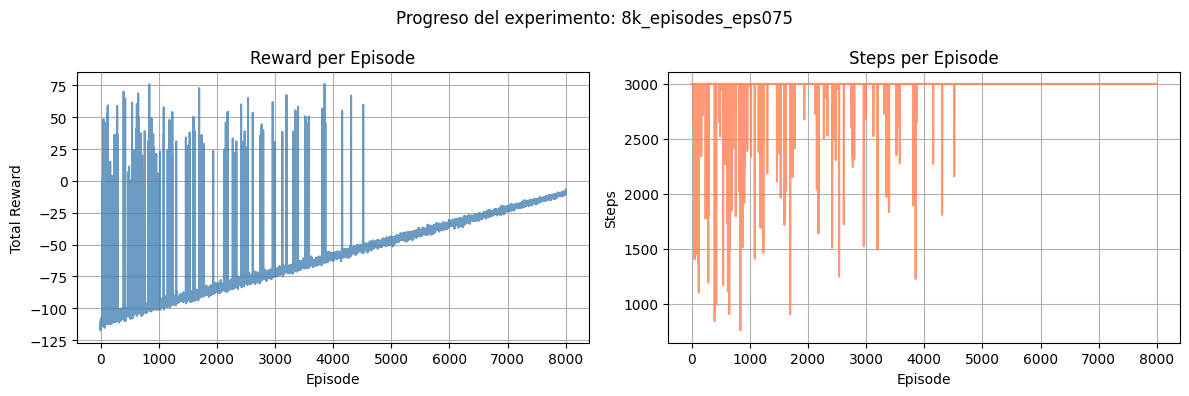

In [17]:
print("Entrenando agente Q-Learning...")
id_e1 = "8k_episodes_eps075"
manager.train_run(
    env, 
    run_id=id_e1,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.075,
    max_steps=3000,
)
env.close()
manager.plot_training_history(id_e1)

Entrenando agente Q-Learning...

[8k_episodes_eps025] Iniciando experimento con Q-Table de tamaño: (101, 101, 20)
[8k_episodes_eps025] Ep 1600/8000 - Avg Reward: -95.02, Steps: 3000
[8k_episodes_eps025] Ep 3200/8000 - Avg Reward: -74.68, Steps: 3000
[8k_episodes_eps025] Ep 4800/8000 - Avg Reward: -56.07, Steps: 3000
[8k_episodes_eps025] Ep 6400/8000 - Avg Reward: -35.13, Steps: 3000
[8k_episodes_eps025] Ep 8000/8000 - Avg Reward: -14.40, Steps: 3000
--> Experimento '8k_episodes_eps025' guardado con éxito en el historial.


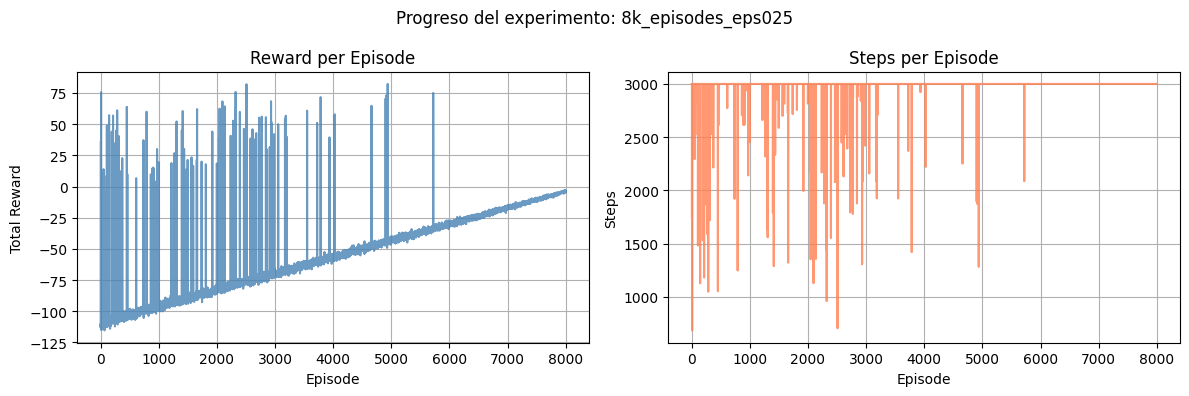

In [18]:
# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_e2 = "8k_episodes_eps025"
manager.train_run(
    env, 
    run_id=id_e2,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.025,
    max_steps=3000,
)
env.close()
manager.plot_training_history(id_e2)

Entrenando agente Q-Learning...
[8k_episodes_eps001] ¡Tabla Q reiniciada a ceros para este experimento!
[8k_episodes_eps001] Ep 800/8000 - Avg Reward: -99.16, Steps: 3000
[8k_episodes_eps001] Ep 1600/8000 - Avg Reward: -90.55, Steps: 3000
[8k_episodes_eps001] Ep 2400/8000 - Avg Reward: -80.97, Steps: 3000
[8k_episodes_eps001] Ep 3200/8000 - Avg Reward: -69.99, Steps: 3000
[8k_episodes_eps001] Ep 4000/8000 - Avg Reward: -59.45, Steps: 3000
[8k_episodes_eps001] Ep 4800/8000 - Avg Reward: -49.08, Steps: 3000
[8k_episodes_eps001] Ep 5600/8000 - Avg Reward: -38.95, Steps: 3000
[8k_episodes_eps001] Ep 6400/8000 - Avg Reward: -28.21, Steps: 3000
[8k_episodes_eps001] Ep 7200/8000 - Avg Reward: -17.41, Steps: 3000
[8k_episodes_eps001] Ep 8000/8000 - Avg Reward: -6.60, Steps: 3000


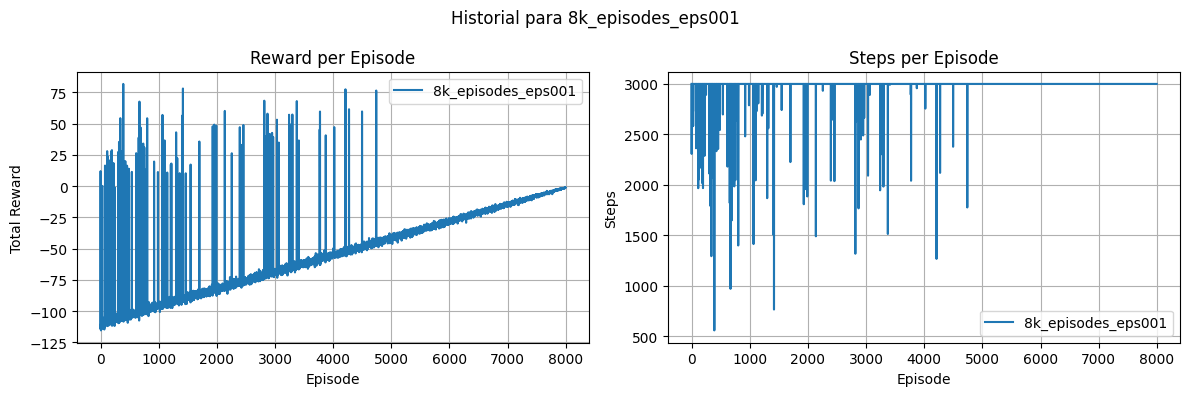

In [ ]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_e3 = "8k_episodes_eps001"
manager.train_run(
    env, 
    run_id=id_e3,
    x_bins=100,
    vel_bins=100,    
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_e3)

In [18]:
print("\nTesteando agente entrenado...")
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
test_rewards, test_steps = agent.test_agent(env, episodes=15, render=True)
env.close()

print(f"\nPromedio de rewards en testing: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps en testing: {np.mean(test_steps):.2f}")


Testeando agente entrenado...


KeyboardInterrupt: 

Entrenando agente Q-Learning...

[5500_episodes_eps0005] Iniciando experimento con Q-Table de tamaño: (101, 101, 20)
[5500_episodes_eps0005] Ep 1100/5500 - Avg Reward: -95.60, Steps: 3000
[5500_episodes_eps0005] Ep 2200/5500 - Avg Reward: -75.19, Steps: 3000
[5500_episodes_eps0005] Ep 3300/5500 - Avg Reward: -54.61, Steps: 3000
[5500_episodes_eps0005] Ep 4400/5500 - Avg Reward: -33.58, Steps: 3000
[5500_episodes_eps0005] Ep 5500/5500 - Avg Reward: -12.04, Steps: 3000
--> Experimento '5500_episodes_eps0005' guardado con éxito en el historial.


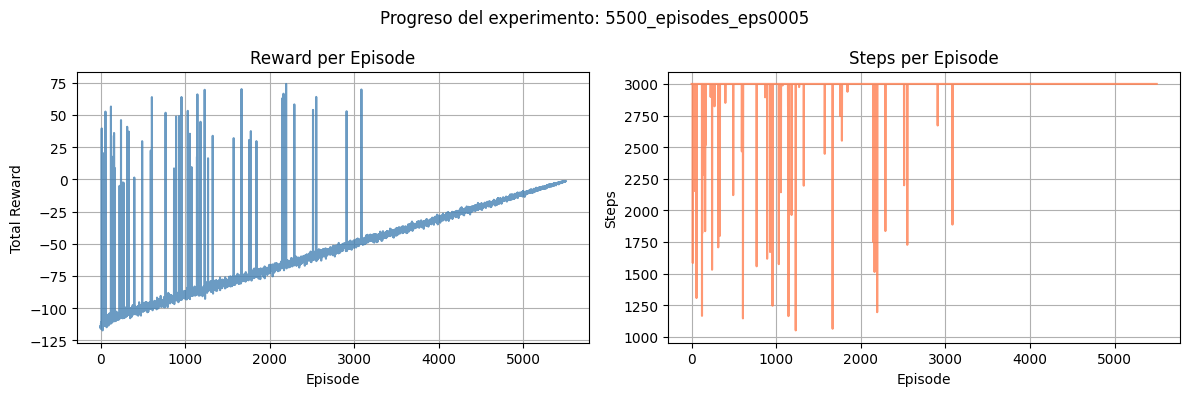

In [21]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_e4 = "5500_episodes_eps0005"
manager.train_run(
    env, 
    run_id=id_e4,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=5500,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.0005,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_e4)

In [21]:
print("\nTesteando agente entrenado...")
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
test_rewards, test_steps = agent.test_agent(env, episodes=5, max_steps=3000)
env.close()

print(f"\nPromedio de rewards en testing: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps en testing: {np.mean(test_steps):.2f}")


Testeando agente entrenado...


KeyboardInterrupt: 

Disminucion de cantidad de pasos

Entrenando agente Q-Learning...

[5500_episodes_eps0005_v2] Iniciando experimento con Q-Table de tamaño: (101, 101, 20)
[5500_episodes_eps0005_v2] Ep 1100/5500 - Avg Reward: -65.16, Steps: 2000
[5500_episodes_eps0005_v2] Ep 2200/5500 - Avg Reward: -51.29, Steps: 2000
[5500_episodes_eps0005_v2] Ep 3300/5500 - Avg Reward: -36.82, Steps: 2000
[5500_episodes_eps0005_v2] Ep 4400/5500 - Avg Reward: -22.38, Steps: 2000
[5500_episodes_eps0005_v2] Ep 5500/5500 - Avg Reward: -7.99, Steps: 2000
--> Experimento '5500_episodes_eps0005_v2' guardado con éxito en el historial.


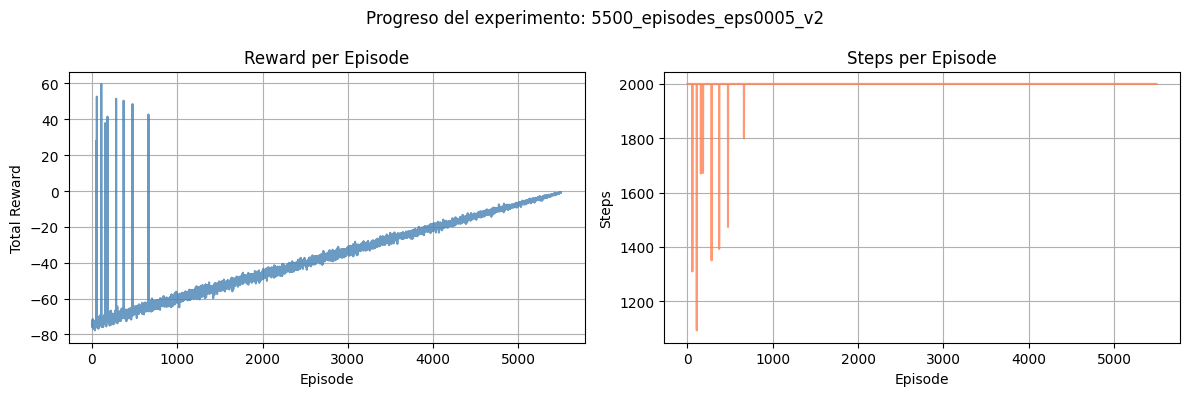

In [22]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_ep1 = "5500_episodes_eps0005_v2"
manager.train_run(
    env, 
    run_id=id_ep1,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=5500,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.0005,
    max_steps=2000
)
env.close()
manager.plot_training_history(id_ep1)

Entrenando agente Q-Learning...

[3k_episodes_eps0005] Iniciando experimento con Q-Table de tamaño: (101, 101, 20)
[3k_episodes_eps0005] Ep 600/3000 - Avg Reward: -65.76, Steps: 2000
[3k_episodes_eps0005] Ep 1200/3000 - Avg Reward: -51.50, Steps: 2000
[3k_episodes_eps0005] Ep 1800/3000 - Avg Reward: -36.73, Steps: 2000
[3k_episodes_eps0005] Ep 2400/3000 - Avg Reward: -22.35, Steps: 2000
[3k_episodes_eps0005] Ep 3000/3000 - Avg Reward: -8.09, Steps: 2000
--> Experimento '3k_episodes_eps0005' guardado con éxito en el historial.


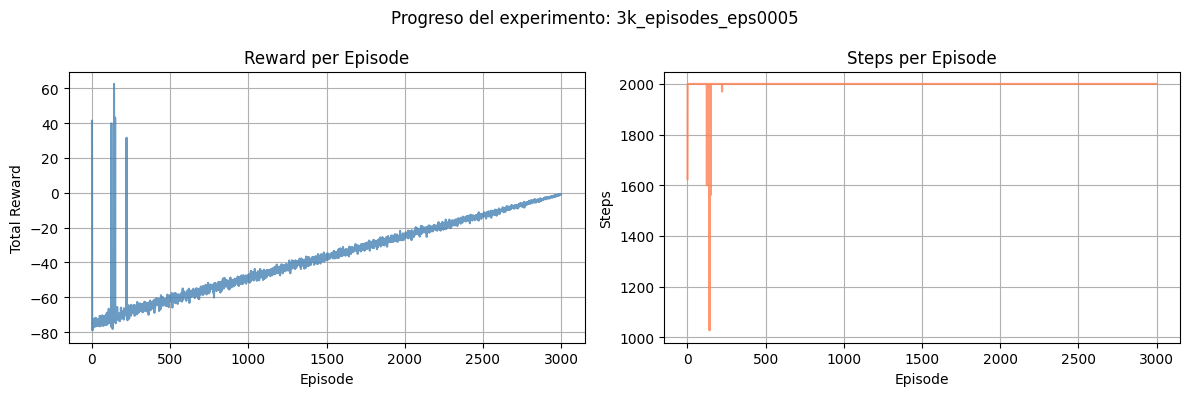

In [23]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_ep2 = "3k_episodes_eps0005"
manager.train_run(
    env, 
    run_id=id_ep2,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=3000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.0005,
    max_steps=2000
)
env.close()
manager.plot_training_history(id_ep2)

Variando el epsilon start

Entrenando agente Q-Learning...

[8k_episodes_eps075] Iniciando experimento con Q-Table de tamaño: (101, 101, 20)
[8k_episodes_eps075] Ep 1600/8000 - Avg Reward: -76.19, Steps: 3000
[8k_episodes_eps075] Ep 3200/8000 - Avg Reward: -59.32, Steps: 3000
[8k_episodes_eps075] Ep 4800/8000 - Avg Reward: -43.40, Steps: 3000
[8k_episodes_eps075] Ep 6400/8000 - Avg Reward: -27.62, Steps: 3000
[8k_episodes_eps075] Ep 8000/8000 - Avg Reward: -11.70, Steps: 3000
--> Experimento '8k_episodes_eps075' guardado con éxito en el historial.


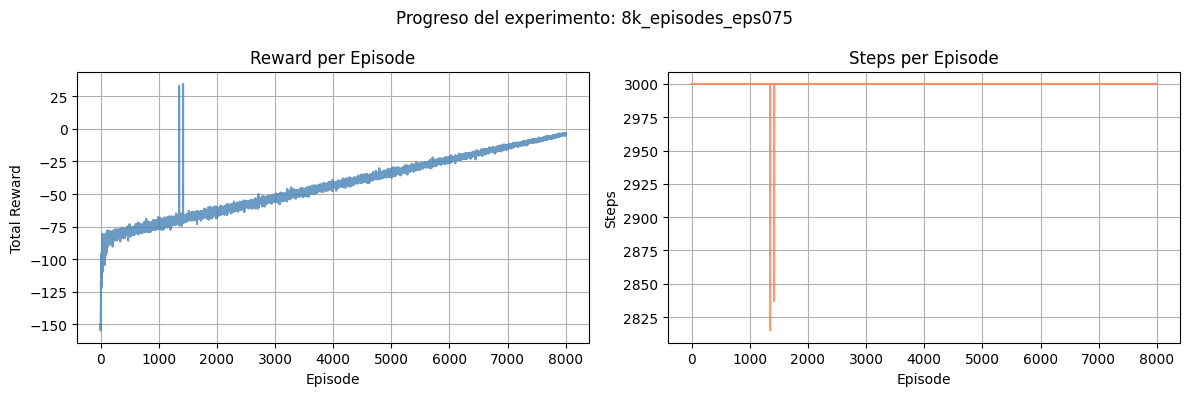

In [24]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_es1= "8k_episodes_eps075"
manager.train_run(
    env, 
    run_id=id_es1,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.75, 
    epsilon_end=0.025,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_es1)

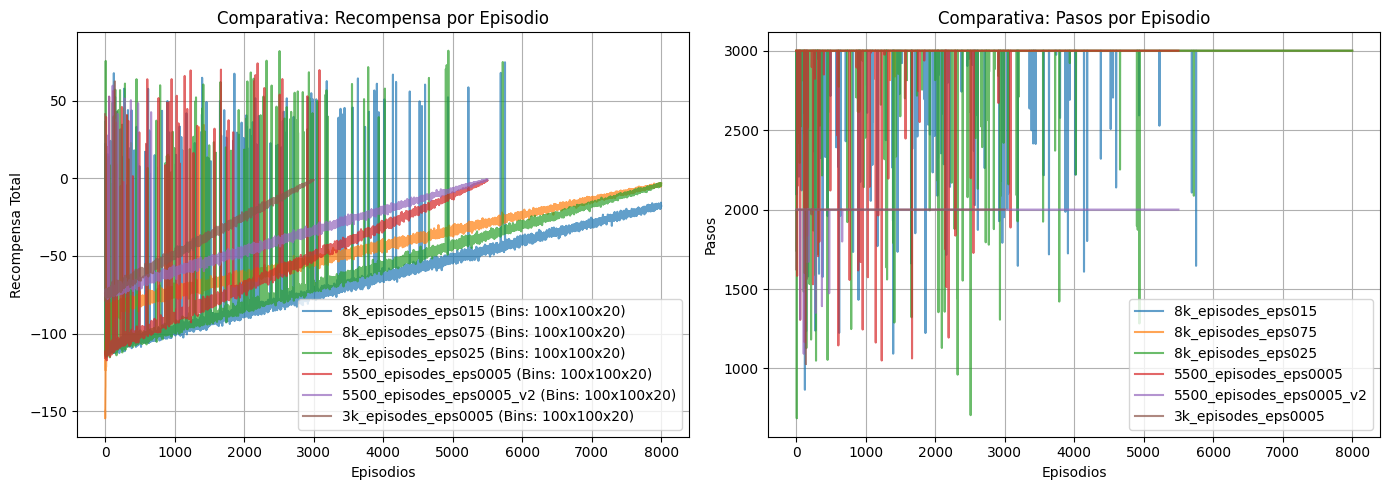

In [25]:
manager.plot_comparisons()

# Analsis para mejorar dicretización

## Q learning

## Setup

In [ ]:
import gymnasium as gym
from q_experiments_manager import ExperimentManager
from q_learning_agent import QLearningAgent
from discretization_evaluator import DiscretizationEvaluator

env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
manager = ExperimentManager()

In [ ]:
evaluator = DiscretizationEvaluator(manager)

train_kwargs = {
    'episodes': 5000,
    'alpha': 0.05,
    'gamma': 0.99,
    'epsilon_start': 0.99,
    'epsilon_end': 0.0005,
    'max_steps': 3000,
}

## Pruebas variando lo action bins

In [ ]:
evaluator.evaluate_group(
    env=env,
    x_bins_list=[50],
    vel_bins_list=[50],
    action_bins_list=[5, 10, 20],  
    train_kwargs=train_kwargs,
    test_episodes=10,
    test_max_steps=3000,
    prefix="G1_Acciones"
)


=== Iniciando Tanda de 3 combinaciones ===

[1/3] Evaluando: G1_Acciones_x50_v50_a5

[G1_Acciones_x50_v50_a5] Iniciando experimento con Q-Table de tamaño: (51, 51, 5)
[G1_Acciones_x50_v50_a5] Ep 1000/5000 - Avg Reward: -114.13, Steps: 3000
[G1_Acciones_x50_v50_a5] Ep 2000/5000 - Avg Reward: -90.73, Steps: 3000
[G1_Acciones_x50_v50_a5] Ep 3000/5000 - Avg Reward: -67.28, Steps: 3000
[G1_Acciones_x50_v50_a5] Ep 4000/5000 - Avg Reward: -43.08, Steps: 3000
[G1_Acciones_x50_v50_a5] Ep 5000/5000 - Avg Reward: -14.87, Steps: 3000
--> Experimento 'G1_Acciones_x50_v50_a5' guardado con éxito en el historial.
       -> Resultado: Avg Reward=0.00 | Success Rate=0.00

[2/3] Evaluando: G1_Acciones_x50_v50_a10

[G1_Acciones_x50_v50_a10] Iniciando experimento con Q-Table de tamaño: (51, 51, 10)
[G1_Acciones_x50_v50_a10] Ep 1000/5000 - Avg Reward: -97.41, Steps: 3000
[G1_Acciones_x50_v50_a10] Ep 2000/5000 - Avg Reward: -76.52, Steps: 3000
[G1_Acciones_x50_v50_a10] Ep 3000/5000 - Avg Reward: -47.80, Ste

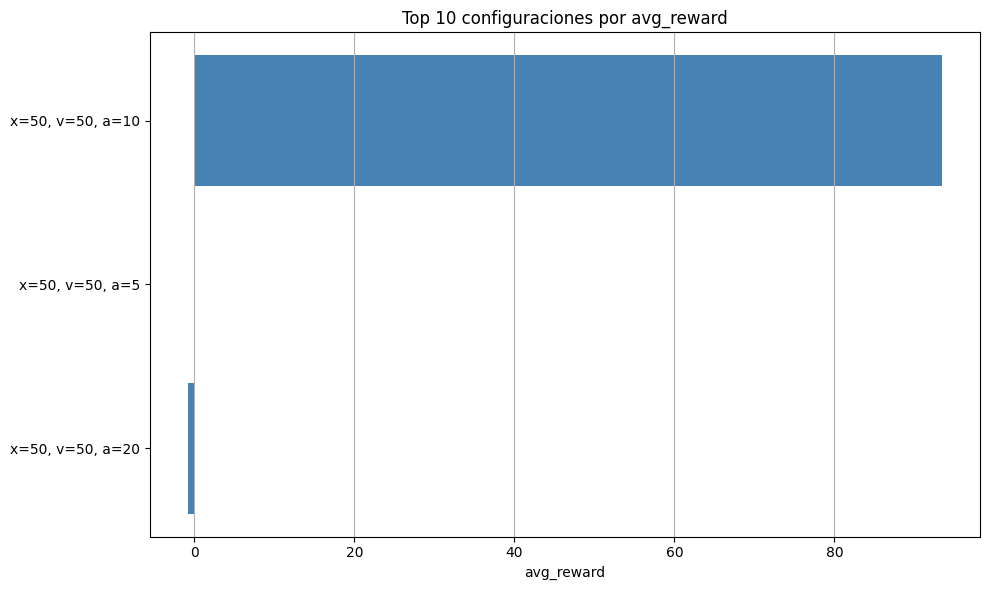

In [18]:
evaluator.plot_ranking()

## Variaciones con mejor resultado anterior

In [19]:
evaluator.evaluate_group(
    env=env,
    x_bins_list=[30, 100],      # <--- Baja y alta resolución de posición
    vel_bins_list=[20, 100],     # <--- Baja y alta resolución de velocidad
    action_bins_list=[10],       # Fijamos el ganador tentativo del grupo anterior
    train_kwargs=train_kwargs,
    test_episodes=10,
    test_max_steps=3000,
    prefix="G2_Estados"
)

env.close()


=== Iniciando Tanda de 4 combinaciones ===

[1/4] Evaluando: G2_Estados_x30_v20_a10

[G2_Estados_x30_v20_a10] Iniciando experimento con Q-Table de tamaño: (31, 21, 10)
[G2_Estados_x30_v20_a10] Ep 1000/5000 - Avg Reward: -98.14, Steps: 3000
[G2_Estados_x30_v20_a10] Ep 2000/5000 - Avg Reward: -42.42, Steps: 2026
[G2_Estados_x30_v20_a10] Ep 3000/5000 - Avg Reward: 53.00, Steps: 492
[G2_Estados_x30_v20_a10] Ep 4000/5000 - Avg Reward: 87.55, Steps: 181
[G2_Estados_x30_v20_a10] Ep 5000/5000 - Avg Reward: 92.74, Steps: 173
--> Experimento 'G2_Estados_x30_v20_a10' guardado con éxito en el historial.
       -> Resultado: Avg Reward=92.56 | Success Rate=1.00

[2/4] Evaluando: G2_Estados_x30_v100_a10

[G2_Estados_x30_v100_a10] Iniciando experimento con Q-Table de tamaño: (31, 101, 10)
[G2_Estados_x30_v100_a10] Ep 1000/5000 - Avg Reward: -98.62, Steps: 3000
[G2_Estados_x30_v100_a10] Ep 2000/5000 - Avg Reward: -75.82, Steps: 3000
[G2_Estados_x30_v100_a10] Ep 3000/5000 - Avg Reward: -47.35, Steps: 

In [20]:
print("\n*** PROCESANDO RESULTADOS DE LOS GRUPOS EJECUTADOS ***")
evaluator.print_summary()


*** PROCESANDO RESULTADOS DE LOS GRUPOS EJECUTADOS ***

=== MEJOR CONFIGURACIÓN EN EL HISTORIAL ACUMULADO ===
x_bins=50, vel_bins=50, action_bins=10
avg_reward=93.47, std_reward=0.76
avg_steps=733.90, success_rate=1.00
q_table_size=26010

=== TOP 5 CONFIGURACIONES GENERALES ===
   x    v    a   avg_reward   std_reward   avg_steps  success       q_size
--------------------------------------------------------------------------
  50   50   10        93.47         0.76      733.90     1.00        26010
  30  100   10        92.63         1.08      750.70     1.00        31310
  30   20   10        92.56         3.22      189.90     1.00         6510
  50   50    5         0.00         0.00     3000.00     0.00        13005
  50   50   20        -0.84         0.00     3000.00     0.00        52020


## Gráficas

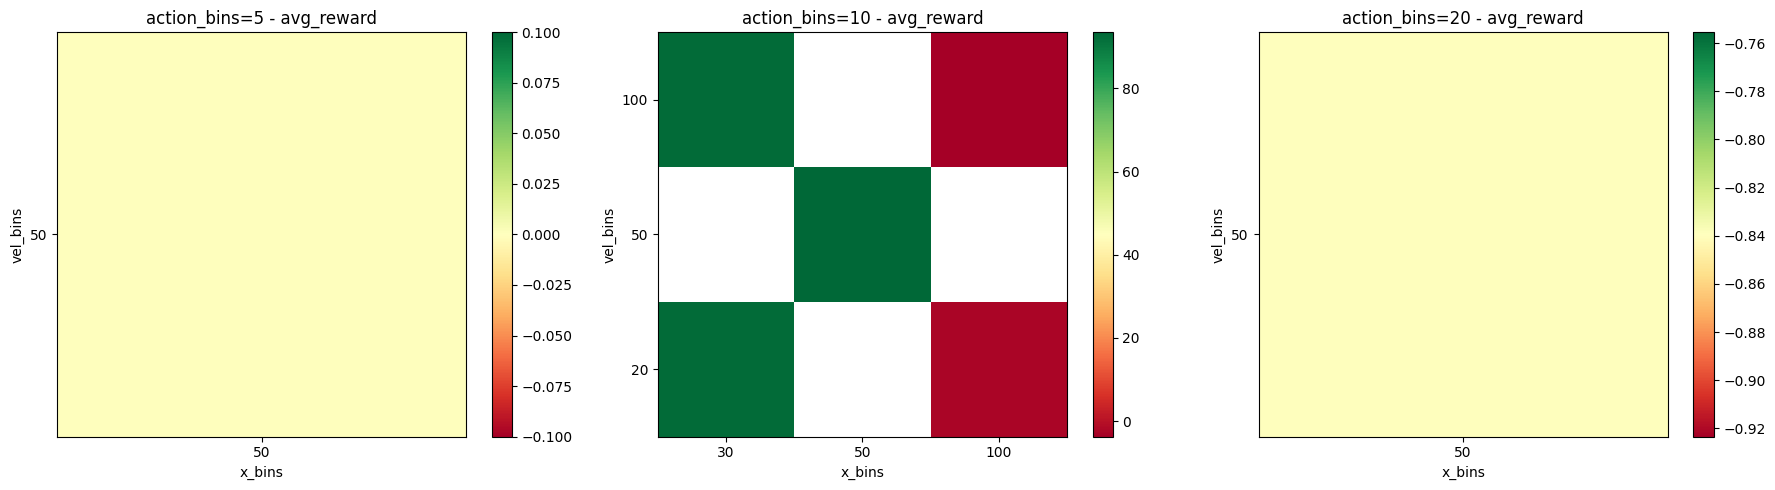

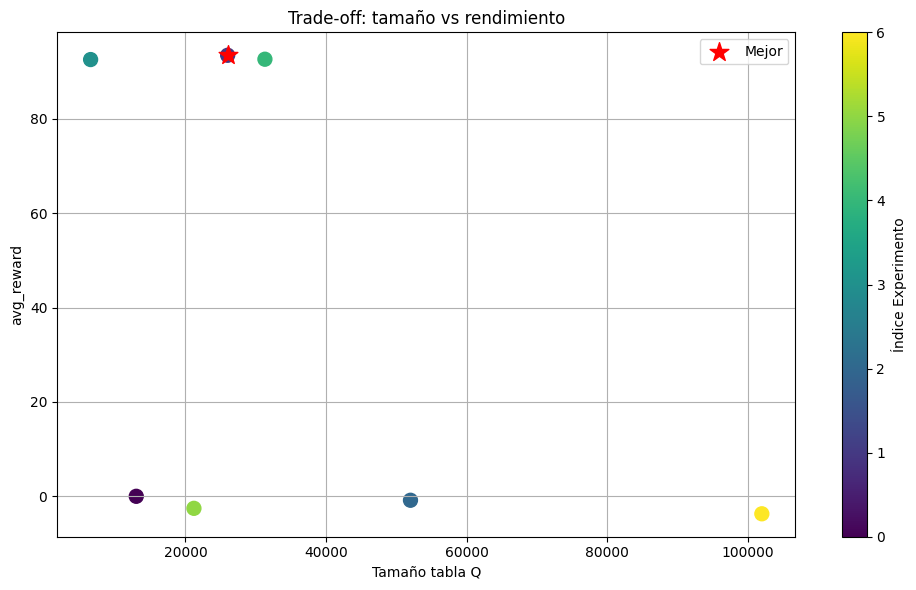

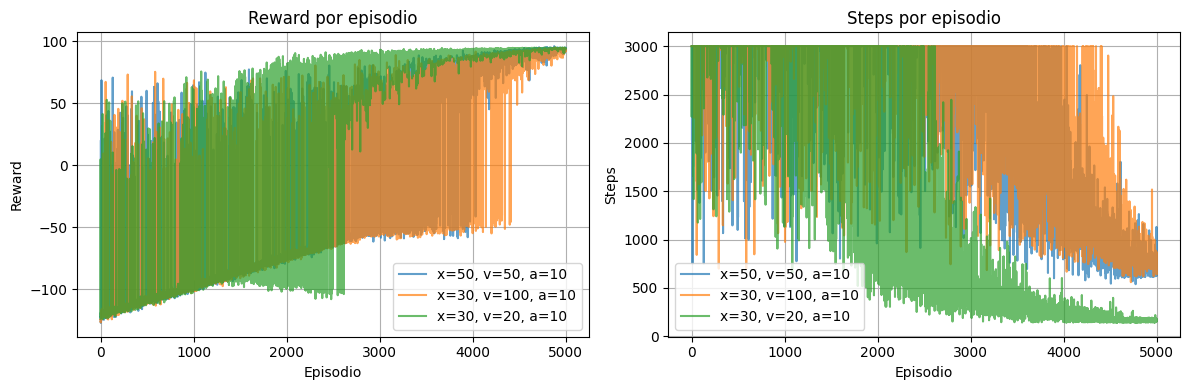

In [21]:
evaluator.plot_heatmap(metric='avg_reward')
evaluator.plot_pareto(metric='avg_reward')
evaluator.plot_convergence(top_n=3)

## Version Anterior

In [68]:
import gymnasium as gym
from q_learning_agent import QLearningAgent
from discretization_search import (
    find_best_discretization,
    print_summary,
    plot_heatmap,
    plot_ranking,
    plot_pareto,
    plot_convergence,
)

In [ ]:
Prueba en etrenamiento y resultado en 10 tests

In [74]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')

train_kwargs = {
    'episodes': 5000,
    'alpha': 0.05,
    'gamma': 0.99,
    'epsilon_start': 0.99,
    'epsilon_end': 0.0005,
    'max_steps': 2000,
}

best, results = find_best_discretization(
    env=env,
    agent_class=QLearningAgent,
    x_bins_list=[30, 50, 100],
    vel_bins_list=[20, 50, 100],
    action_bins_list=[5, 10, 20],
    train_kwargs=train_kwargs,
    test_episodes=10,
    test_max_steps=2000,
    metric='avg_reward'
)

env.close()

[1/27] Probando x_bins=30, vel_bins=20, action_bins=5
Episode 500/5000 - Avg Reward: -82.06, Steps: 921
Episode 1000/5000 - Avg Reward: -75.05, Steps: 2000
Episode 1500/5000 - Avg Reward: -67.16, Steps: 1735
Episode 2000/5000 - Avg Reward: -58.33, Steps: 2000
Episode 2500/5000 - Avg Reward: -42.82, Steps: 1164
Episode 3000/5000 - Avg Reward: 31.09, Steps: 359
Episode 3500/5000 - Avg Reward: 71.86, Steps: 472
Episode 4000/5000 - Avg Reward: 83.70, Steps: 302
Episode 4500/5000 - Avg Reward: 89.44, Steps: 164
Episode 5000/5000 - Avg Reward: 91.00, Steps: 176
       -> avg_reward=91.38, avg_steps=162.80, success_rate=1.00
[2/27] Probando x_bins=30, vel_bins=20, action_bins=10
Episode 500/5000 - Avg Reward: -72.77, Steps: 2000
Episode 1000/5000 - Avg Reward: -66.11, Steps: 2000
Episode 1500/5000 - Avg Reward: -56.71, Steps: 2000
Episode 2000/5000 - Avg Reward: -48.85, Steps: 1562
Episode 2500/5000 - Avg Reward: -29.78, Steps: 2000
Episode 3000/5000 - Avg Reward: 29.72, Steps: 666
Episode 35

KeyboardInterrupt: 

### Graficas/resultados


=== MEJOR CONFIGURACIÓN ===
x_bins=30, vel_bins=20, action_bins=5
avg_reward=0.00, std_reward=0.00
avg_steps=4000.00, success_rate=0.00
q_table_size=3255

=== TOP 5 CONFIGURACIONES ===
   x    v    a   avg_reward   std_reward   avg_steps  success       q_size
--------------------------------------------------------------------------
  30   20    5         0.00         0.00     4000.00     0.00         3255
  30   50    5         0.00         0.00     4000.00     0.00         7905
  30  100    5         0.00         0.00     4000.00     0.00        15655
  50   20    5         0.00         0.00     4000.00     0.00         5355
  50   50    5         0.00         0.00     4000.00     0.00        13005


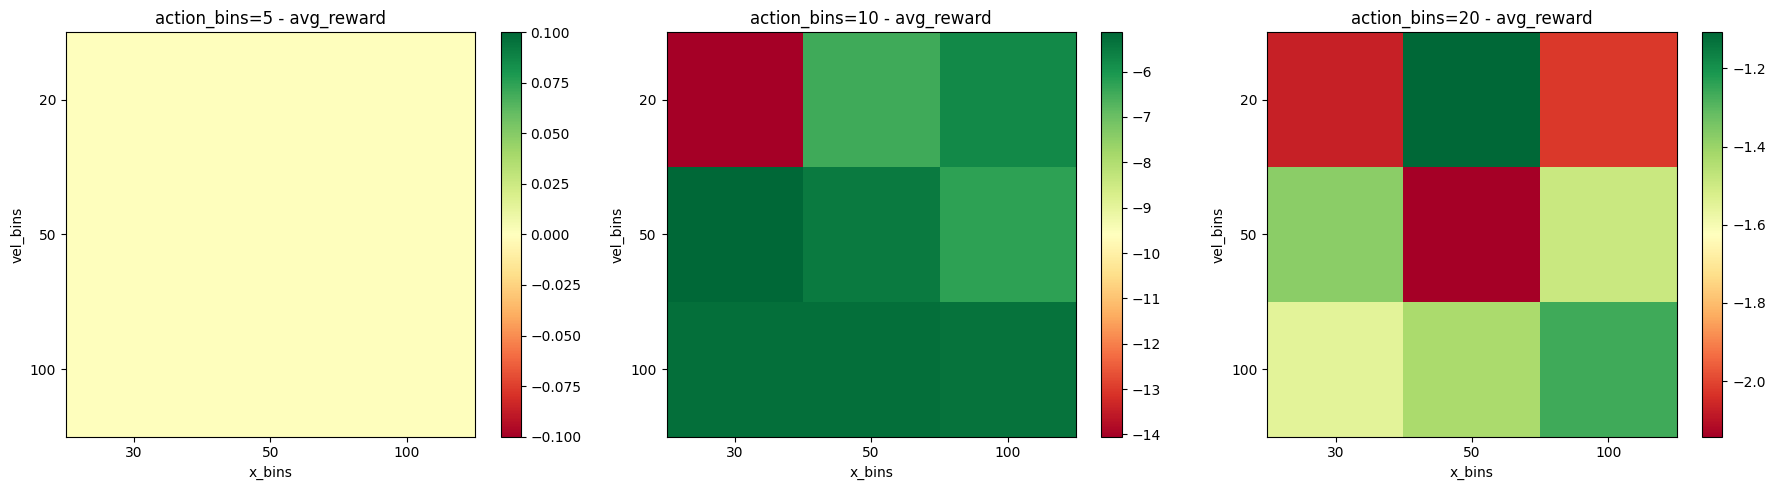

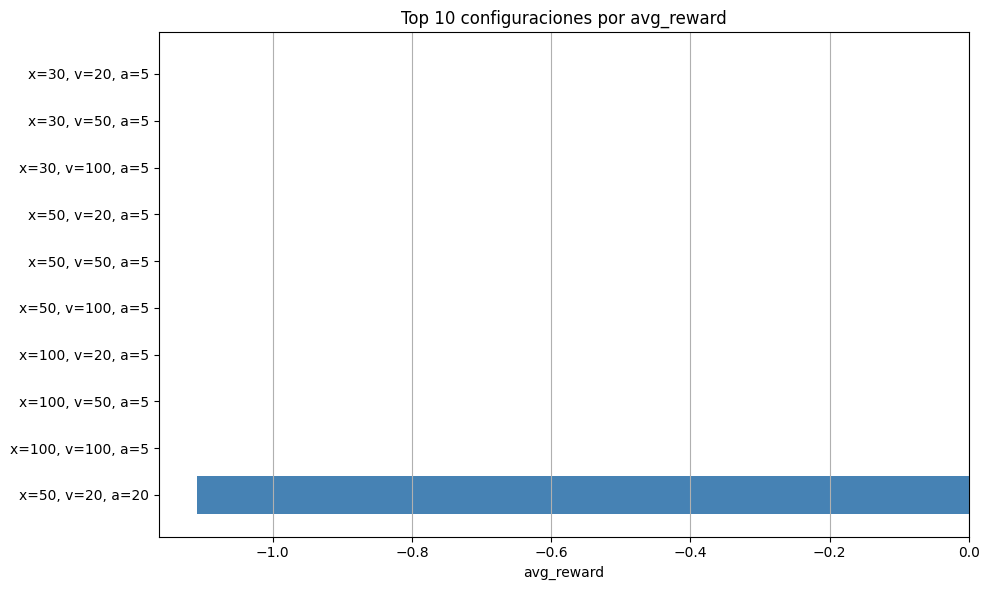

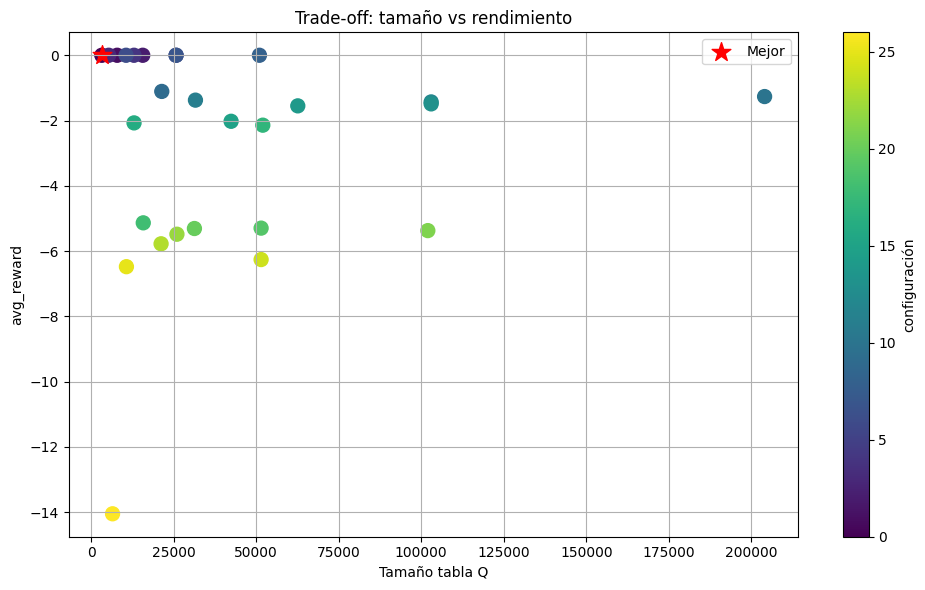

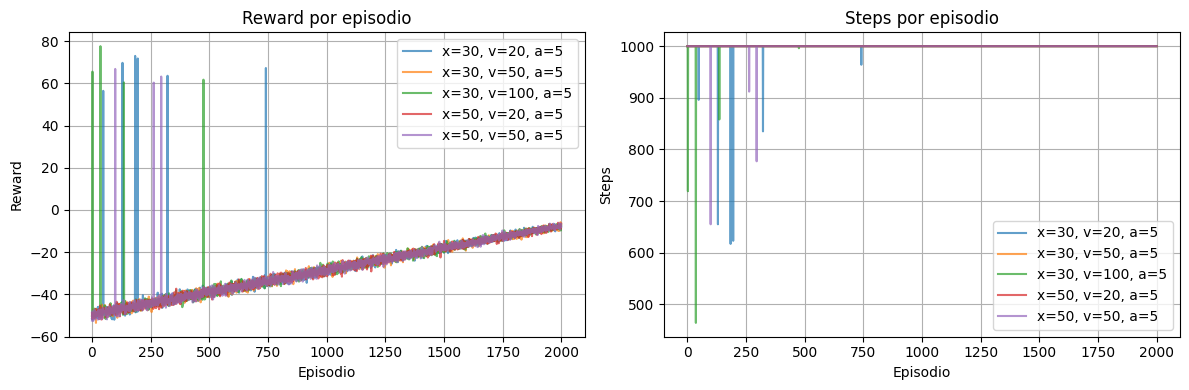

In [71]:
print_summary(best, results)
plot_heatmap(results, metric='avg_reward')
plot_ranking(results, metric='avg_reward', top_n=10)
plot_pareto(results, metric='avg_reward')
plot_convergence(results, top_n=5)